[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oalnaseri/mobilcom_course/blob/main/07_doppler_time_variance_interactive.ipynb)

> **Run this notebook in Google Colab** — click the badge above (no local install needed).
> The setup cell below installs dependencies and enables interactive `ipywidgets` sliders in Colab.

---

# 🚄 Time Variance, Doppler Spectrum & Coherence Time
### Interactive Teaching Notebook — DHBW Mobile Communications
---
The mirror image of the previous notebook. There we had

$$P(\tau)\ \longleftrightarrow\ \rho(\Delta f)\ \longrightarrow\ B_{Korr}$$

here we have

$$\rho(\Delta t)\ \longleftrightarrow\ \Phi(f_D)\ \longrightarrow\ B_{DS},\ T_{Korr}$$

and the whole thing is driven by **motion**. Three scenarios are built in, including the
**railway case** of the lecture: what a noise barrier does to the Doppler spectrum, and
why vegetation is friendlier to an OFDM receiver.

---

In [1]:
# ============================================================
#  COLAB / ENVIRONMENT SETUP  (safe to run locally too)
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # numpy + matplotlib ship with Colab; ensure ipywidgets is present
    !pip install -q ipywidgets

    # Required so ipywidgets sliders / interactive output render in Colab
    from google.colab import output
    output.enable_custom_widget_manager()

print("Environment ready.  IN_COLAB =", IN_COLAB)

Environment ready.  IN_COLAB = False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f5f5f5'
c0 = 3e8
print("Libraries loaded.")

Libraries loaded.


## 📚 Theory Reference

### Doppler shift of one path
A path arriving under the azimuth angle $\varphi$ (measured against the direction of travel)
is shifted by

$$f_D=\frac{v\cdot f_c}{c_0}\cos\varphi
\qquad\Rightarrow\qquad
f_{D,max}=\frac{v f_c}{c_0}\ (\varphi=0^\circ),\quad
f_{D,min}=-\frac{v f_c}{c_0}\ (\varphi=180^\circ)$$

Note what this says: **a constant distance produces no shift.** It is the *rate of change*
of the path length that shifts the frequency.

### Doppler spectrum and Doppler spread
Every path contributes a line at its own $f_D$; together they form the Doppler spectrum
$\Phi(f_D)$. Its width is the **Doppler spread**

$$B_{DS}=\sqrt{\overline{f_D^{2}}-\bar{f_D}^{\,2}}\qquad[\mathrm{Hz}]$$

— exactly the same construction as the delay spread, one domain over.

### Time ACF and coherence time
$\Phi(f_D)$ and the time-ACF are a **Fourier pair**:

$$\rho(\Delta t)=\frac{\left|\sum_i P_i\,e^{\,j2\pi f_{D,i}\Delta t}\right|}{\sum_i P_i}$$

$T_{Korr,x\%}$ is the smallest $\Delta t$ at which $|\rho|$ falls below $x\%$, and

$$\boxed{\ B_{DS}\ \sim\ \frac{1}{T_{Korr,x\%}}\ }$$

### The three scenarios in this notebook
| Scenario | Angles of arrival | Doppler spectrum |
|---|---|---|
| **isotropic** (classic Jakes) | uniform over $360^\circ$ | U-shaped between $\pm f_{D,max}$ |
| **noise barrier** (waveguide) | concentrated at $0^\circ$ and $180^\circ$ | two spikes at $\pm f_{D,max}$ |
| **vegetation** | broad lobes along the track | smooth, filled-in |

---

In [3]:
# ---------------------------------------------------------------
#  CORE FUNCTIONS
# ---------------------------------------------------------------
def f_D_max(v_kmh, fc_MHz):
    """Maximum Doppler shift [Hz]."""
    return (v_kmh / 3.6) * (fc_MHz * 1e6) / c0

def arrival_angles(scenario, n=400, spread_deg=12.0, seed=0):
    """Azimuth angles [rad] and relative path powers for the three scenarios."""
    rng = np.random.default_rng(seed)
    if scenario == 'isotropic':
        phi = rng.uniform(0, 2*np.pi, n)
        w   = np.ones(n)
    elif scenario == 'noise barrier':
        # waveguide: two narrow lobes along the track (0 deg and 180 deg)
        half = n // 2
        phi  = np.concatenate([rng.normal(0.0, np.deg2rad(spread_deg), half),
                               rng.normal(np.pi, np.deg2rad(spread_deg), n-half)])
        w    = np.ones(n)
    elif scenario == 'vegetation':
        # same two lobes, but much wider and with a diffuse floor
        half = n // 2
        phi  = np.concatenate([rng.normal(0.0, np.deg2rad(4*spread_deg), half),
                               rng.normal(np.pi, np.deg2rad(4*spread_deg), n-half)])
        phi  = np.concatenate([phi, rng.uniform(0, 2*np.pi, n//2)])
        w    = np.concatenate([np.ones(n), 0.35*np.ones(n//2)])
    else:
        raise ValueError(scenario)
    return phi, w

def doppler_lines(phi, w, fdmax):
    """Doppler frequency of every path [Hz]."""
    return fdmax * np.cos(phi), w

def doppler_spread(fd, w):
    """B_DS and the mean Doppler shift [Hz]."""
    W  = w.sum()
    m1 = (w*fd).sum() / W
    m2 = (w*fd**2).sum() / W
    return np.sqrt(max(m2 - m1**2, 0.0)), m1

def time_acf(fd, w, dt):
    """|rho(dt)| = |FT{Doppler spectrum}| , normalised."""
    ph = np.exp(2j*np.pi*np.outer(dt, fd))
    return np.abs(ph @ w) / w.sum()

def coherence_time(fd, w, level=0.37, dt_max=None, n=6000):
    if dt_max is None:
        dt_max = 5.0 / max(np.abs(fd).max(), 1e-9)
    dt = np.linspace(0, dt_max, n)
    r  = time_acf(fd, w, dt)
    below = np.where(r < level)[0]
    return (dt[below[0]] if below.size else None), dt, r

def envelope(fd, w, t, seed=0):
    """One realisation of the complex envelope h(t) = sum a_i exp(j(2pi fd_i t + th_i))."""
    rng = np.random.default_rng(seed)
    a   = np.sqrt(w) * rng.rayleigh(1.0, w.size)
    th  = rng.uniform(0, 2*np.pi, w.size)
    h   = (a*np.exp(1j*th)) @ np.exp(2j*np.pi*np.outer(fd, t))
    return h / np.sqrt((np.abs(h)**2).mean())

print("Core functions defined.")

Core functions defined.


v = 300 km/h = 83.3 m/s,   f_c = 2000 MHz
f_D,max = v*f_c/c0 = 555.6 Hz      f_D,min = -555.6 Hz
total width of the Doppler spectrum = 1111.1 Hz


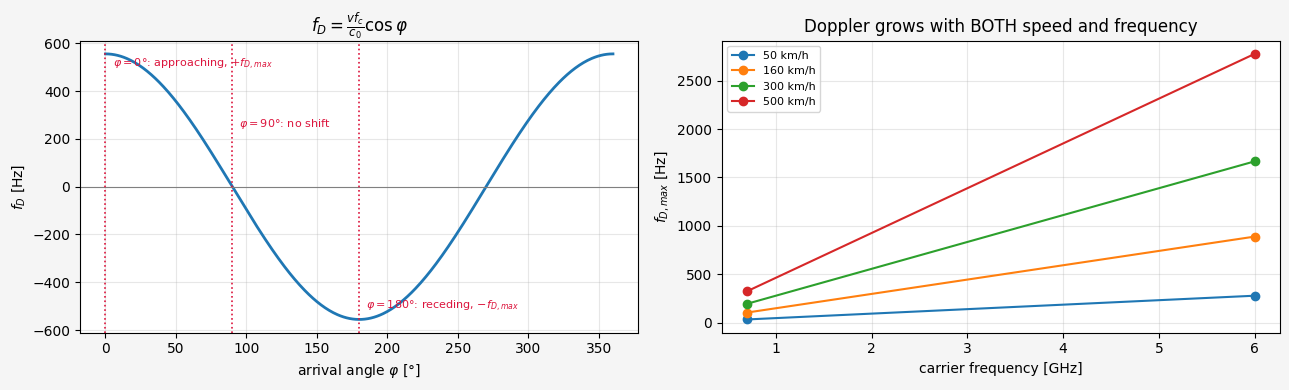

In [4]:
# ---------------------------------------------------------------
#  A FIRST LOOK:  f_D over the arrival angle
# ---------------------------------------------------------------
v_kmh, fc_MHz = 300.0, 2000.0          # ICE at 300 km/h, 2 GHz (as in the lecture)
fdm = f_D_max(v_kmh, fc_MHz)
print(f"v = {v_kmh:.0f} km/h = {v_kmh/3.6:.1f} m/s,   f_c = {fc_MHz:.0f} MHz")
print(f"f_D,max = v*f_c/c0 = {fdm:.1f} Hz      f_D,min = {-fdm:.1f} Hz")
print(f"total width of the Doppler spectrum = {2*fdm:.1f} Hz")

phi = np.linspace(0, 2*np.pi, 500)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(np.rad2deg(phi), fdm*np.cos(phi), lw=2, color="C0")
ax[0].axhline(0, color="gray", lw=.8)
for a_, ypos, lab in [(0,   0.90, r"$\varphi=0°$: approaching, $+f_{D,max}$"),
                      (90,  0.45, r"$\varphi=90°$: no shift"),
                      (180, -0.92, r"$\varphi=180°$: receding, $-f_{D,max}$")]:
    ax[0].axvline(a_, color="crimson", ls=":", lw=1.2)
    ax[0].text(a_+5, fdm*ypos, lab, fontsize=8, color="crimson")
ax[0].set_xlabel(r"arrival angle $\varphi$ [°]"); ax[0].set_ylabel(r"$f_D$ [Hz]")
ax[0].set_title(r"$f_D=\frac{v f_c}{c_0}\cos\varphi$"); ax[0].grid(alpha=.3)

for v in [50, 160, 300, 500]:
    ax[1].plot([0.7, 6], [f_D_max(v, 700), f_D_max(v, 6000)], marker="o",
               label=f"{v} km/h")
ax[1].set_xlabel("carrier frequency [GHz]"); ax[1].set_ylabel(r"$f_{D,max}$ [Hz]")
ax[1].set_title("Doppler grows with BOTH speed and frequency")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

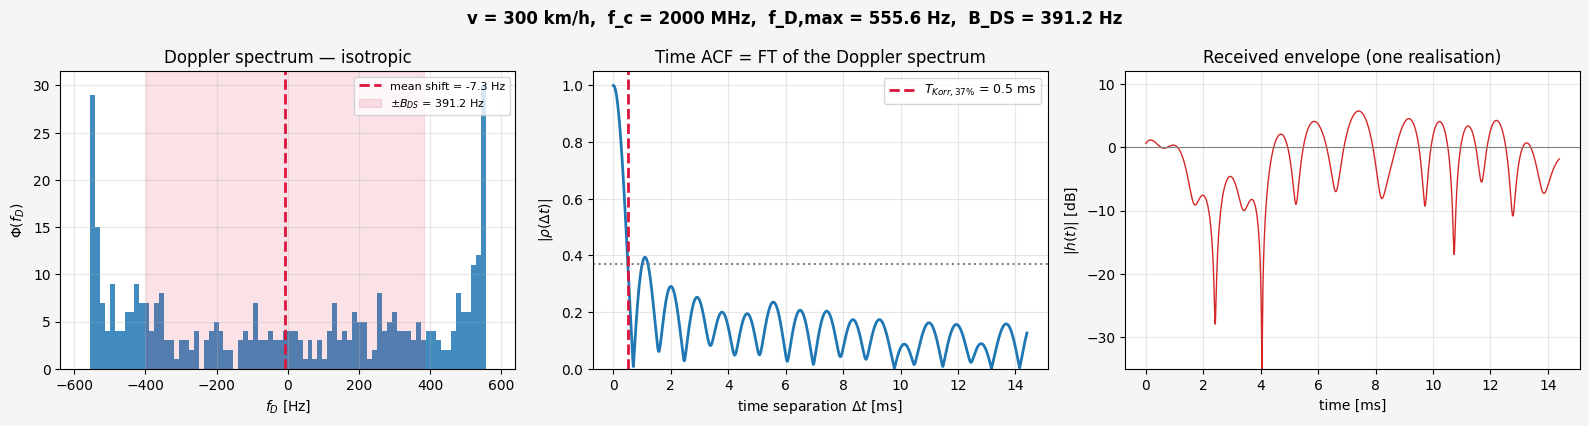

     isotropic:  B_DS =  391.2 Hz    T_Korr,37% = 0.5 ms


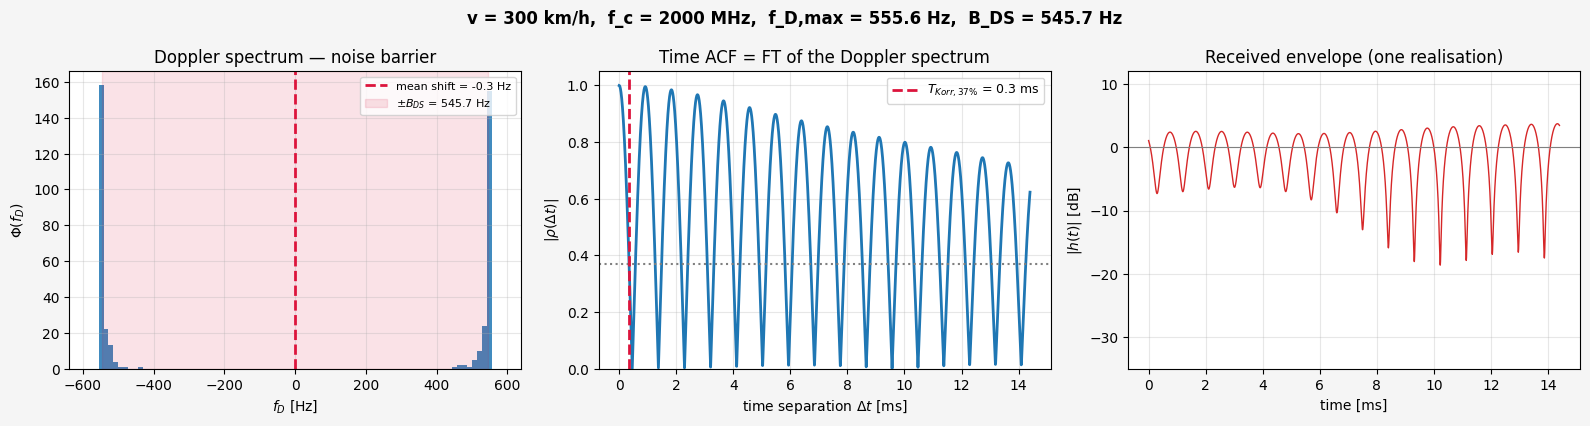

 noise barrier:  B_DS =  545.7 Hz    T_Korr,37% = 0.3 ms


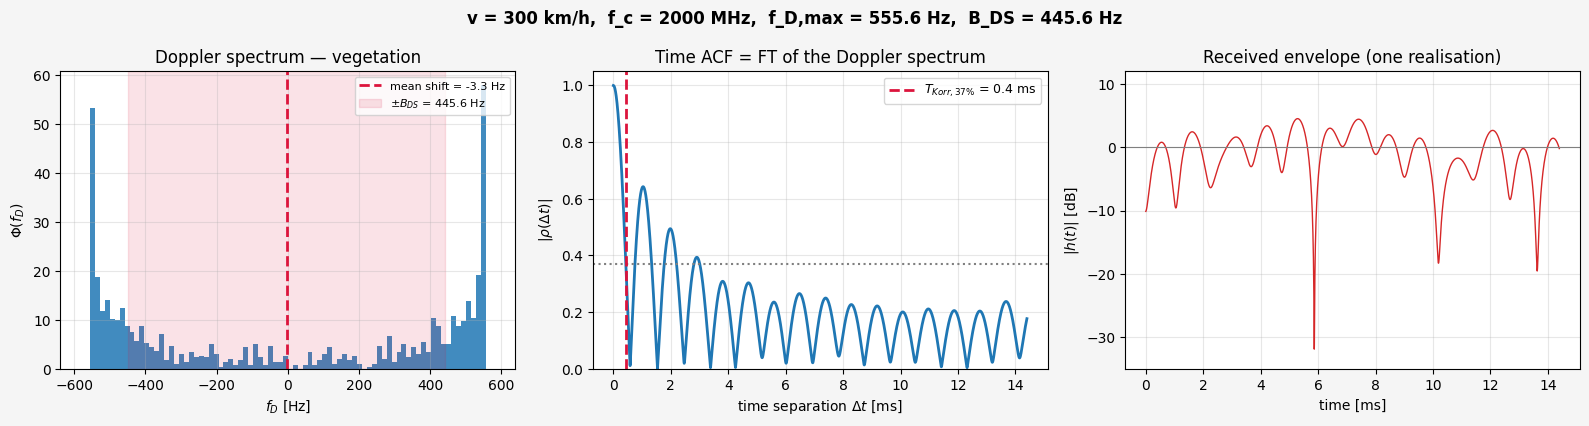

    vegetation:  B_DS =  445.6 Hz    T_Korr,37% = 0.4 ms


In [5]:
# ---------------------------------------------------------------
#  THE FULL PICTURE FOR ONE SCENARIO
# ---------------------------------------------------------------
def plot_doppler_scene(v_kmh=300, fc_MHz=2000, scenario='isotropic',
                       spread_deg=12.0, level=0.37, seed=1):
    fdm      = f_D_max(v_kmh, fc_MHz)
    phi, w   = arrival_angles(scenario, spread_deg=spread_deg, seed=seed)
    fd, w    = doppler_lines(phi, w, fdm)
    Bds, fbar= doppler_spread(fd, w)
    Tc, dt, r= coherence_time(fd, w, level, dt_max=8.0/max(fdm, 1e-9))

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

    # 1) Doppler spectrum -------------------------------------------------
    ax[0].hist(fd, bins=80, weights=w, color="C0", alpha=.85)
    ax[0].axvline(fbar, color="crimson", ls="--", lw=2,
                  label=fr"mean shift = {fbar:.1f} Hz")
    ax[0].axvspan(fbar-Bds, fbar+Bds, color="crimson", alpha=.12,
                  label=fr"$\pm B_{{DS}}$ = {Bds:.1f} Hz")
    ax[0].set_xlim(-1.15*fdm, 1.15*fdm)
    ax[0].set_xlabel(r"$f_D$ [Hz]"); ax[0].set_ylabel(r"$\Phi(f_D)$")
    ax[0].set_title(f"Doppler spectrum — {scenario}")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    # 2) time ACF ---------------------------------------------------------
    ax[1].plot(dt*1000, r, lw=2, color="C0")
    ax[1].axhline(level, color="gray", ls=":", lw=1.5)
    if Tc is not None:
        ax[1].axvline(Tc*1000, color="crimson", ls="--", lw=2,
                      label=fr"$T_{{Korr,{int(level*100)}\%}}$ = {Tc*1000:.1f} ms")
    else:
        ax[1].plot([], [], ' ', label=f"never reaches {level:.2f}")
    ax[1].set_xlabel(r"time separation $\Delta t$ [ms]")
    ax[1].set_ylabel(r"$|\rho(\Delta t)|$")
    ax[1].set_title("Time ACF = FT of the Doppler spectrum")
    ax[1].set_ylim(0, 1.05); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

    # 3) the fading the receiver actually sees -----------------------------
    t = np.linspace(0, 8.0/max(fdm, 1e-9), 4000)
    h = envelope(fd, w, t, seed=seed)
    ax[2].plot(t*1000, 20*np.log10(np.abs(h)), lw=1.0, color="C3")
    ax[2].axhline(0, color="gray", lw=.8)
    ax[2].set_xlabel("time [ms]"); ax[2].set_ylabel(r"$|h(t)|$ [dB]")
    ax[2].set_ylim(-35, 12)
    ax[2].set_title("Received envelope (one realisation)")
    ax[2].grid(alpha=.3)

    fig.suptitle(f"v = {v_kmh:.0f} km/h,  f_c = {fc_MHz:.0f} MHz,  "
                 f"f_D,max = {fdm:.1f} Hz,  B_DS = {Bds:.1f} Hz",
                 fontsize=12, fontweight="bold")
    fig.tight_layout(); plt.show()
    return Bds, Tc

for sc in ['isotropic', 'noise barrier', 'vegetation']:
    B, T = plot_doppler_scene(scenario=sc)
    tt = f"{T*1000:.1f} ms" if T else "-- (never decorrelates)"
    print(f"{sc:>14s}:  B_DS = {B:6.1f} Hz    T_Korr,37% = {tt}")

In [6]:
# ---------------------------------------------------------------
#  INTERACTIVE EXPLORER
# ---------------------------------------------------------------
style  = {'description_width': '200px'}
layout = widgets.Layout(width='540px')

sl_v   = widgets.FloatSlider(value=300, min=5, max=500, step=5,
            description='speed v [km/h]:', style=style, layout=layout)
sl_fc  = widgets.FloatSlider(value=2000, min=400, max=6000, step=100,
            description='carrier f_c [MHz]:', style=style, layout=layout)
dd_sc  = widgets.Dropdown(options=['isotropic', 'noise barrier', 'vegetation'],
            value='isotropic', description='scenario:', style=style, layout=layout)
sl_sp  = widgets.FloatSlider(value=12, min=2, max=40, step=1,
            description='lobe width [deg]:', style=style, layout=layout)
sl_lv  = widgets.FloatSlider(value=0.37, min=0.1, max=0.9, step=0.01,
            description='correlation level x:', style=style, layout=layout)

def update(v, fc, sc, sp, lv):
    Bds, Tc = plot_doppler_scene(v, fc, sc, sp, lv)
    fdm = f_D_max(v, fc)
    print(f"f_D,max = {fdm:7.1f} Hz     B_DS = {Bds:7.1f} Hz", end="")
    if Tc:
        print(f"     T_Korr = {Tc*1000:6.2f} ms     B_DS x T_Korr = {Bds*Tc:.2f}")
    else:
        print("     T_Korr = none at this level")
    # OFDM sanity check (LTE numerology)
    print(f"LTE subcarrier spacing 15 kHz  ->  f_D,max / 15 kHz = {fdm/15e3*100:.3f} %"
          f"  of the spacing (inter-carrier interference stays small below ~1 %).")

ui  = widgets.VBox([sl_v, sl_fc, dd_sc, sl_sp, sl_lv])
out = widgets.interactive_output(update, {'v': sl_v, 'fc': sl_fc, 'sc': dd_sc,
                                          'sp': sl_sp, 'lv': sl_lv})
display(ui, out)

Output()

## 📝 Try this

1. **The lecture's ICE case.** 300 km/h at 2 GHz gives $f_{D,max} \approx 556$ Hz, so the
   spectrum is about 1.1 kHz wide. Now push the carrier to 6 GHz — the spread triples
   without the train getting any faster. That is why high-speed rail is hard at mmWave.
2. **Noise barrier vs. vegetation.** Switch between the two scenarios at the same speed.
   With the barrier the energy piles up at $\pm f_{D,max}$ — exactly the "concentration of
   Doppler shifts" on the slide. With vegetation the spectrum fills in and smooths out.
   Look at the third panel: which one gives the nastier fading?
3. **Watch the time ACF for the barrier case.** Narrow the lobe width to 2–3°: the curve
   stops decaying smoothly and starts to *oscillate and come back up*, because a two-line
   spectrum transforms into a cosine. The channel then becomes periodically good and bad —
   a very different problem from random fading, and much harder on a channel estimator.
4. **The OFDM line printed under the plot.** Inter-carrier interference becomes a worry
   once $f_{D,max}$ approaches about 1 % of the subcarrier spacing. At which speed and
   carrier frequency does LTE's 15 kHz spacing get uncomfortable?
5. **Mast spacing.** At 300 km/h, how long does the train take to travel between two mast
   pairs 50 m apart? Compare that with $T_{Korr}$ — is the channel constant over one pass?

## 📌 Summary

| Time domain | Frequency domain |
|---|---|
| time ACF $\rho(\Delta t)$ | Doppler spectrum $\Phi(f_D)$ |
| **coherence time** $T_{Korr,x\%}$ | **Doppler spread** $B_{DS}$ |
| large $T_{Korr}$ = slow channel | small $B_{DS}$ = slow channel |

Fast movement $\Rightarrow$ wide Doppler spectrum $\Rightarrow$ short coherence time
$\Rightarrow$ the channel estimate goes stale quickly and pilots must be sent more often.